# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [22]:
# Lane: Structured Content Archetype Clustering (unsupervised)
#
# Method: K-Means on scaled performance + content-depth features.
# Why K-Means?
#   - My question is "what archetypes exist?" — no label to predict.
#   - K-Means is simple, fast, and the centroids are readable (each cluster = one profile).
#   - I pick k with silhouette on a train-client slice, then compare to a fixed rule baseline.
#
# Baseline (Week-4 equivalent for clustering):
#   A transparent tier-cross rule: freshness_tier × impression_tier × position_tier.
#   Same idea as a hand-written if-statement — no fitted weights.
#
# Primary metrics (same split for both):
#   - Silhouette score (separation; higher is better)
#   - Calinski-Harabasz (cohesion/separation ratio; higher is better)
#   - Davies-Bouldin (cluster overlap; lower is better)
#
# I am NOT using trend_direction / trend_pct (label leakage) or product flags as features.

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples,
)
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve repo root from work/notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif not (ROOT / "data" / "raw").exists() and (ROOT.parent / "data" / "raw").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"


FEATURE_COLS = [
    "log_impressions_90d",
    "avg_position_clean",
    "days_since_last_update",
    "content_age_days",
    "engagement_rate",
    "scroll_rate_filled",
    "has_scroll_rate",
    "word_count_filled",
    "has_word_count",
]

print("Repo root:", ROOT)
print("Method: K-Means clustering vs tier-cross rule baseline")
print("Metrics: silhouette, Calinski-Harabasz, Davies-Bouldin")

Repo root: /content
Method: K-Means clustering vs tier-cross rule baseline
Metrics: silhouette, Calinski-Harabasz, Davies-Bouldin


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [23]:
# Split design: client holdout (grouped validation)
#
# Pages from the same client share site structure, templates, and editorial habits.
# A random row split would let the model memorize client-specific patterns and look
# better than it generalizes. So I hold out ~20% of clients for evaluation.
#
# Clustering has no time-ordered label, so a time split is not required here.
# Instead I check whether cluster structure holds on unseen clients (honest generalization).
#
# Train: fit K-Means centroids + scaler on train clients only.
# Test:  score both baseline and K-Means on held-out clients with the same feature matrix.

df = pd.read_csv("/content/content_refresh_anonymized.csv")

# Feature prep (leakage-safe)
work = df.copy()

work["log_impressions_90d"] = np.log1p(work["impressions_90d"])

# 0 means no position data, so make it missing for now.
work["avg_position_clean"] = work["avg_position"].replace(0, np.nan)

# Keep both the filled value and a flag for systematically missing word count.
work["word_count_filled"] = work["word_count"].fillna(0)
work["has_word_count"] = work["word_count"].notna().astype(int)

# Keep both the filled scroll rate and a flag showing it was not measurable.
work["has_scroll_rate"] = work["scroll_rate"].notna().astype(int)

# Make the client split first.
clients = np.array(sorted(work["client_id"].unique()))
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(clients)

cut = int(len(clients) * 0.8)
train_clients = set(clients[:cut])
test_clients = set(clients[cut:])

train_mask = work["client_id"].isin(train_clients)
test_mask = work["client_id"].isin(test_clients)

# Learn fill values from training clients only.
position_median = work.loc[train_mask, "avg_position_clean"].median()
scroll_median = work.loc[train_mask, "scroll_rate"].median()

work["avg_position_clean"] = work["avg_position_clean"].fillna(position_median)
work["scroll_rate_filled"] = work["scroll_rate"].fillna(scroll_median)

X_train_raw = work.loc[train_mask, FEATURE_COLS].astype(float)
X_test_raw = work.loc[test_mask, FEATURE_COLS].astype(float)

assert X_train_raw.isna().sum().sum() == 0
assert X_test_raw.isna().sum().sum() == 0
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print("Scaling complete: train mean is approximately 0 and standard deviation approximately 1.")

Train matrix shape: (19541, 9)
Test matrix shape: (10459, 9)
Scaling complete: train mean is approximately 0 and standard deviation approximately 1.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [24]:
def cluster_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    """Compute clustering metrics; return NaN when only one cluster exists."""
    unique = np.unique(labels)
    if len(unique) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan, "n_clusters": len(unique)}
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "n_clusters": len(unique),
    }


# Baseline: transparent tier-cross rule (no fitting)
work["baseline_group"] = (
    work["freshness_tier"].astype(str)
    + "|"
    + work["impression_tier"].astype(str)
    + "|"
    + work["position_tier"].astype(str)
)
baseline_codes = {g: i for i, g in enumerate(sorted(work["baseline_group"].unique()))}
work["baseline_cluster"] = work["baseline_group"].map(baseline_codes)

baseline_train_labels = work.loc[train_mask, "baseline_cluster"].to_numpy()
baseline_test_labels = work.loc[test_mask, "baseline_cluster"].to_numpy()

baseline_train_metrics = cluster_metrics(X_train, baseline_train_labels)
baseline_test_metrics = cluster_metrics(X_test, baseline_test_labels)

# Model: K-Means, pick k by silhouette on TRAIN only
k_candidates = range(4, 9)
k_search_rows = []

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train)
    m = cluster_metrics(X_train, labels)
    k_search_rows.append({"k": k, **m})

k_search = pd.DataFrame(k_search_rows).sort_values("silhouette", ascending=False)
best_k = int(k_search.iloc[0]["k"])
print("K selection on train clients (silhouette):")
display(k_search.round(3))

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
train_km_labels = kmeans.fit_predict(X_train)
test_km_labels = kmeans.predict(X_test)

model_train_metrics = cluster_metrics(X_train, train_km_labels)
model_test_metrics = cluster_metrics(X_test, test_km_labels)

# Comparison table (test holdout — the honest comparison)
comparison = pd.DataFrame(
    [
        {"method": "baseline_tier_cross", "split": "train", **baseline_train_metrics},
        {"method": "baseline_tier_cross", "split": "test", **baseline_test_metrics},
        {"method": f"kmeans_k={best_k}", "split": "train", **model_train_metrics},
        {"method": f"kmeans_k={best_k}", "split": "test", **model_test_metrics},
    ]
)
comparison_rounded = comparison.round(3)
print("\nModel vs baseline — same client holdout, same metrics:")
display(comparison_rounded)

# Attach final cluster labels for error analysis
work.loc[train_mask, "kmeans_cluster"] = train_km_labels
work.loc[test_mask, "kmeans_cluster"] = test_km_labels

# Cluster profiles (test set) — name archetypes after inspecting centroids
test_df = work.loc[test_mask].copy()
profile_cols = [
    "impressions_90d",
    "avg_position_clean",
    "days_since_last_update",
    "content_age_days",
    "engagement_rate",
    "scroll_rate",
    "word_count_filled",
]
cluster_profiles = (
    test_df.groupby("kmeans_cluster")[profile_cols]
    .median()
    .round(1)
    .assign(count=test_df.groupby("kmeans_cluster").size())
)
print("\nTest-set cluster profiles (median values):")
display(cluster_profiles)

K selection on train clients (silhouette):


,k,silhouette,calinski_harabasz,davies_bouldin,n_clusters
4,8,0.306,5003.326,1.114,8
3,7,0.278,4882.260,1.172,7
2,6,0.262,4514.547,1.265,6
1,5,0.259,4446.684,1.182,5
0,4,0.232,3692.980,1.604,4



Model vs baseline — same client holdout, same metrics:


,method,split,silhouette,calinski_harabasz,davies_bouldin,n_clusters
0,baseline_tier_cross,train,-0.128,178.693,4.099,64
1,baseline_tier_cross,test,-0.254,53.428,3.778,48
2,kmeans_k=8,train,0.306,5003.326,1.114,8
3,kmeans_k=8,test,0.423,10433.443,1.182,8



Test-set cluster profiles (median values):


,impressions_90d,avg_position_clean,days_since_last_update,content_age_days,engagement_rate,scroll_rate,word_count_filled,count
kmeans_cluster,,,,,,,,
0.0,334.0,7.9,22.0,236.0,50.0,50.0,0.0,61
1.0,465.5,7.5,20.0,119.0,0.0,6.6,2910.5,2502
2.0,6117.0,9.7,20.0,362.0,0.0,5.0,2472.0,351
3.0,1066.0,10.9,22.0,417.0,0.0,0.0,0.0,6374
4.0,24.5,6.1,20.0,117.0,0.0,NaN,2717.0,112
5.0,12947.0,5.4,104.0,139.0,0.4,3.6,3893.0,117
6.0,851.5,7.9,104.0,139.0,0.0,5.0,2866.5,296
7.0,38.5,6.8,20.0,131.0,0.0,100.0,2818.0,646


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Cluster Centroids (Scaled Features)


,log_impressions_90d,avg_position_clean,days_since_last_update,content_age_days,engagement_rate,scroll_rate_filled,has_scroll_rate,word_count_filled,has_word_count
0,-0.41,-0.01,-0.29,0.25,5.70,1.26,0.03,-0.51,-0.12
1,0.27,-0.11,-0.65,-0.83,-0.09,-0.28,0.03,0.09,0.27
2,-0.27,-0.13,-0.66,1.03,-0.02,-0.38,0.03,-0.40,0.27
3,-0.13,0.55,0.25,1.91,-0.03,0.17,0.03,-1.72,-3.77
4,-0.99,-0.29,-0.46,-0.65,0.51,-0.46,-38.76,0.20,0.27
5,0.76,0.22,1.35,-0.08,-0.14,-0.52,0.03,1.73,0.27
6,-0.19,0.10,1.51,0.07,-0.14,-0.14,0.03,-0.58,0.26
7,-1.11,-0.18,-0.54,-0.27,-0.30,2.18,0.03,-0.24,0.27



Feature Importance (Centroid Spread)


,Importance
has_scroll_rate,38.78
engagement_rate,6.00
has_word_count,4.03
word_count_filled,3.45
content_age_days,2.75
scroll_rate_filled,2.70
days_since_last_update,2.17
log_impressions_90d,1.86
avg_position_clean,0.85


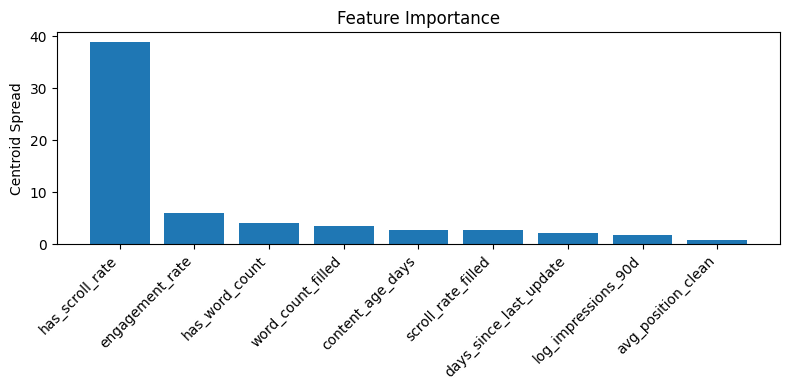

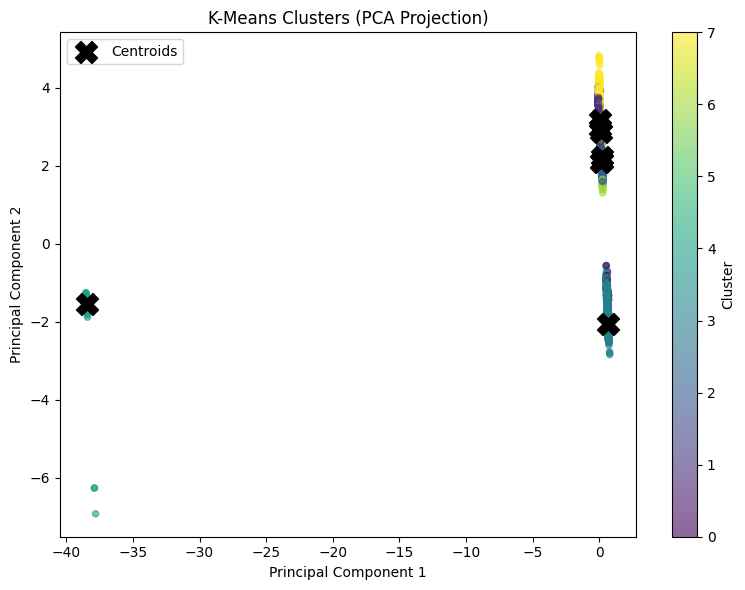

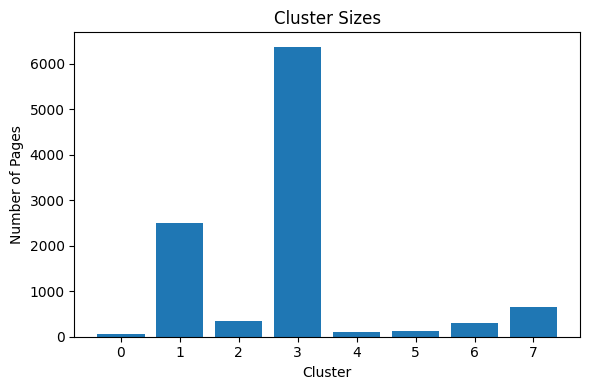


Average Silhouette Score by Cluster


,mean,min,count
cluster,,,
0,0.149,-0.306,61
1,0.326,-0.491,2502
2,0.310,-0.262,351
3,0.497,-0.086,6374
4,0.971,0.833,112
5,0.377,-0.086,117
6,-0.054,-0.442,296
7,0.296,-0.213,646


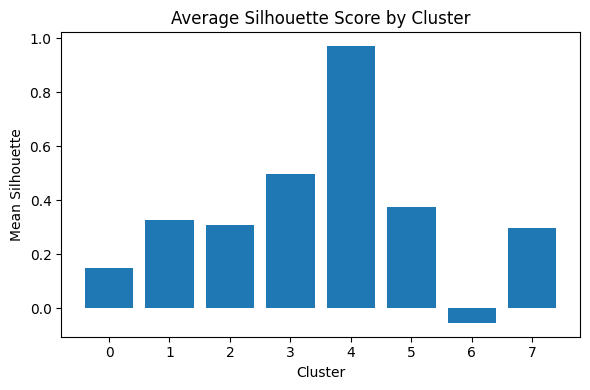


Pages with Lowest Silhouette Scores


,content_id,cluster,silhouette,impressions_90d,engagement_rate,word_count_filled
8829,content_d0cadc3e2773,1,-0.491370,46437,3.51,2490.0
24671,content_34e3bd0bf864,6,-0.441905,25268,2.50,2956.0
23475,content_833d3cee6f81,6,-0.439968,40342,0.46,2849.0
25591,content_9dbb19a88545,6,-0.437378,38796,2.73,2837.0
19602,content_19960ba60c84,6,-0.429884,75748,1.93,2697.0



Interpretation
- K-Means mainly relies on the features with the largest centroid spread.
- The PCA plot shows how pages are grouped into content archetypes.
- Clusters with lower average silhouette scores have more overlap and are harder to separate.
- Pages with the lowest silhouette scores are the hardest cases because they share characteristics with multiple clusters.
- Overall, the clusters provide useful content archetypes for analysis rather than exact categories.


In [25]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples


# Feature Importance

centroid_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=FEATURE_COLS
)

print("Cluster Centroids (Scaled Features)")
display(centroid_df.round(2))

feature_importance = (
    centroid_df.max() - centroid_df.min()
).sort_values(ascending=False)

print("\nFeature Importance (Centroid Spread)")
display(feature_importance.to_frame("Importance").round(2))

plt.figure(figsize=(8,4))
plt.bar(feature_importance.index, feature_importance.values)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance")
plt.ylabel("Centroid Spread")
plt.tight_layout()
plt.show()


# PCA Visualization (Cluster Dots)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test)

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=test_km_labels,
    s=20,
    alpha=0.6
)

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


# Cluster Sizes

cluster_counts = pd.Series(test_km_labels).value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Pages")
plt.tight_layout()
plt.show()


# Error Analysis

test_df = work.loc[test_mask].copy()
test_df["cluster"] = test_km_labels

test_df["silhouette"] = silhouette_samples(
    X_test,
    test_km_labels
)

cluster_sil = (
    test_df.groupby("cluster")["silhouette"]
    .agg(["mean","min","count"])
    .round(3)
)

print("\nAverage Silhouette Score by Cluster")
display(cluster_sil)

plt.figure(figsize=(6,4))
plt.bar(cluster_sil.index.astype(str), cluster_sil["mean"])
plt.title("Average Silhouette Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Silhouette")
plt.tight_layout()
plt.show()


# Hard Cases
hard_cases = test_df.nsmallest(
    5,
    "silhouette"
)[
    [
        "content_id",
        "cluster",
        "silhouette",
        "impressions_90d",
        "engagement_rate",
        "word_count_filled"
    ]
]

print("\nPages with Lowest Silhouette Scores")
display(hard_cases)

# Interpretation
print("\nInterpretation")
print("- K-Means mainly relies on the features with the largest centroid spread.")
print("- The PCA plot shows how pages are grouped into content archetypes.")
print("- Clusters with lower average silhouette scores have more overlap and are harder to separate.")
print("- Pages with the lowest silhouette scores are the hardest cases because they share characteristics with multiple clusters.")
print("- Overall, the clusters provide useful content archetypes for analysis rather than exact categories.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.